# Task 1: News Topic Classifier Using BERT

**Objective:** Fine-tune BERT to classify news headlines into topic categories.

**Dataset:** AG News Dataset (Hugging Face)

**Model:** `bert-base-uncased`

**Environment:** Google Colab (T4 GPU recommended)

> Before running: Go to `Runtime → Change runtime type → T4 GPU`

## 1. Install Dependencies

In [1]:
!pip install transformers datasets scikit-learn accelerate -q
print('Dependencies installed.')

Dependencies installed.


## 2. Import Libraries

In [2]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import (
    BertTokenizer,
    BertForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {device}')
if device == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')

Using device: cuda
GPU: Tesla T4


## 3. Load and Explore the Dataset

AG News has 4 categories: World (0), Sports (1), Business (2), Sci/Tech (3)

In [3]:
dataset = load_dataset('ag_news')

print(dataset)
print('\nSample entry:')
print(dataset['train'][0])

LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
print(f'\nLabel mapping: {dict(enumerate(LABEL_NAMES))}')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 120000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 7600
    })
})

Sample entry:
{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}

Label mapping: {0: 'World', 1: 'Sports', 2: 'Business', 3: 'Sci/Tech'}


In [4]:
from collections import Counter

TRAIN_SIZE = 4000
TEST_SIZE  = 800

train_data = dataset['train'].shuffle(seed=42).select(range(TRAIN_SIZE))
test_data  = dataset['test'].shuffle(seed=42).select(range(TEST_SIZE))

print(f'Training samples : {len(train_data)}')
print(f'Testing samples  : {len(test_data)}')

train_labels = Counter(train_data['label'])
print('\nClass distribution (train):')
for label, count in sorted(train_labels.items()):
    print(f'  {LABEL_NAMES[label]}: {count}')

Training samples : 4000
Testing samples  : 800

Class distribution (train):
  World: 1007
  Sports: 1000
  Business: 942
  Sci/Tech: 1051


## 4. Tokenize the Dataset

In [5]:
MODEL_NAME = 'bert-base-uncased'
tokenizer  = BertTokenizer.from_pretrained(MODEL_NAME)

def tokenize(batch):
    return tokenizer(
        batch['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

train_tokenized = train_data.map(tokenize, batched=True)
test_tokenized  = test_data.map(tokenize, batched=True)

cols = ['input_ids', 'attention_mask', 'token_type_ids', 'label']
train_tokenized.set_format('torch', columns=cols)
test_tokenized.set_format('torch', columns=cols)

print('Tokenization complete.')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/4000 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Tokenization complete.


## 5. Load Pre-trained BERT Model

In [6]:
model = BertForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=4
)
model.to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f'Model: {MODEL_NAME}')
print(f'Total parameters: {total_params:,}')

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model: bert-base-uncased
Total parameters: 109,485,316


## 6. Define Evaluation Metrics

In [7]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = np.argmax(logits, axis=-1)
    acc = accuracy_score(labels, predictions)
    f1  = f1_score(labels, predictions, average='weighted')
    return {'accuracy': acc, 'f1': f1}

print('Metrics function defined.')

Metrics function defined.


## 7. Configure Training Arguments

In [9]:
training_args = TrainingArguments(
    output_dir='./bert_news_classifier',
    num_train_epochs=3,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=100,
    learning_rate=2e-5,
    weight_decay=0.01,
    fp16=True if device == 'cuda' else False,
    eval_strategy='epoch',
    save_strategy='epoch',
    load_best_model_at_end=True,
    logging_steps=50,
    report_to='none'
)

print('Training configuration set.')

Training configuration set.


## 8. Train the Model

In [10]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_tokenized,
    eval_dataset=test_tokenized,
    compute_metrics=compute_metrics
)

print('Starting fine-tuning...')
trainer.train()
print('Fine-tuning complete!')

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,0.345675,0.330757,0.900000,0.899707
2,0.228243,0.319237,0.906250,0.906369
3,0.130911,0.336162,0.898750,0.898857


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

Fine-tuning complete!


## 9. Evaluate the Model

In [11]:
results = trainer.evaluate()
print('Evaluation Results:')
print(f"  Accuracy : {results['eval_accuracy']:.4f}")
print(f"  F1 Score : {results['eval_f1']:.4f}")

Evaluation Results:
  Accuracy : 0.9062
  F1 Score : 0.9064


In [12]:
predictions = trainer.predict(test_tokenized)
preds  = np.argmax(predictions.predictions, axis=-1)
labels = predictions.label_ids

print('Classification Report:')
print(classification_report(labels, preds, target_names=LABEL_NAMES))

Classification Report:
              precision    recall  f1-score   support

       World       0.96      0.85      0.90       202
      Sports       0.96      0.99      0.97       193
    Business       0.91      0.85      0.88       205
    Sci/Tech       0.82      0.94      0.87       200

    accuracy                           0.91       800
   macro avg       0.91      0.91      0.91       800
weighted avg       0.91      0.91      0.91       800



## 10. Visualise Results

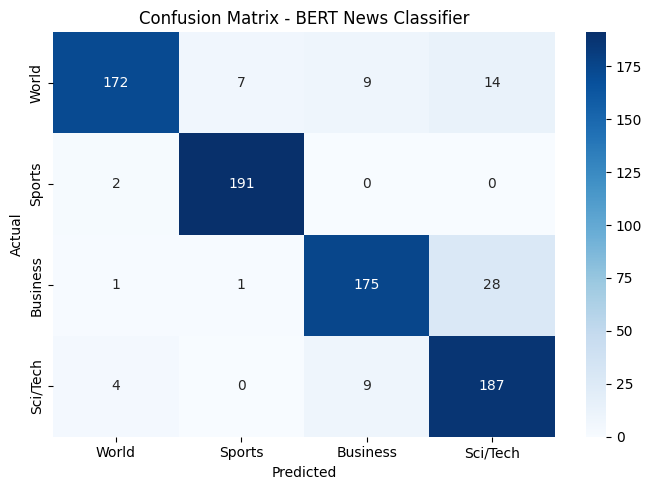

In [13]:
cm = confusion_matrix(labels, preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=LABEL_NAMES, yticklabels=LABEL_NAMES)
plt.title('Confusion Matrix - BERT News Classifier')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('bert_confusion_matrix.png', dpi=150)
plt.show()

## 11. Save the Model

In [14]:
SAVE_PATH = './bert_news_classifier_final'
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)
print(f'Model saved to: {SAVE_PATH}')

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Model saved to: ./bert_news_classifier_final


## 12. Live Inference - Test with Custom Headlines

In [15]:
from transformers import pipeline

classifier = pipeline(
    'text-classification',
    model='./bert_news_classifier_final',
    tokenizer='./bert_news_classifier_final',
    device=0 if device == 'cuda' else -1
)

test_headlines = [
    'NASA launches new Mars rover mission',
    'Stock markets rally after Fed rate decision',
    'Champions League final ends in dramatic penalty shootout',
    'G7 leaders meet to discuss global trade policies',
    'Apple unveils new AI-powered iPhone features'
]

label_map = {f'LABEL_{i}': name for i, name in enumerate(LABEL_NAMES)}

print('Live Predictions:\n')
for headline in test_headlines:
    result = classifier(headline)[0]
    category   = label_map[result['label']]
    confidence = result['score'] * 100
    print(f'Headline   : {headline}')
    print(f'Category   : {category} ({confidence:.1f}% confidence)\n')

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

Live Predictions:

Headline   : NASA launches new Mars rover mission
Category   : Sci/Tech (98.9% confidence)

Headline   : Stock markets rally after Fed rate decision
Category   : Business (94.4% confidence)

Headline   : Champions League final ends in dramatic penalty shootout
Category   : Sports (98.3% confidence)

Headline   : G7 leaders meet to discuss global trade policies
Category   : Business (59.8% confidence)

Headline   : Apple unveils new AI-powered iPhone features
Category   : Sci/Tech (99.0% confidence)



## 13. Deploy with Gradio for Live Interaction

In [16]:
!pip install gradio -q
print('Gradio installed.')

Gradio installed.


In [17]:
import gradio as gr

LABEL_NAMES = ['World', 'Sports', 'Business', 'Sci/Tech']
label_map   = {f'LABEL_{i}': name for i, name in enumerate(LABEL_NAMES)}

def predict(headline):
    if not headline.strip():
        return {name: 0.0 for name in LABEL_NAMES}
    results = classifier(headline, top_k=None)
    if isinstance(results[0], list):
        results = results[0]
    return {label_map[r['label']]: round(r['score'], 4) for r in results}

demo = gr.Interface(
    fn=predict,
    inputs=gr.Textbox(
        label='News Headline',
        placeholder='Enter a news headline here...',
        lines=2
    ),
    outputs=gr.Label(
        label='Category Probabilities',
        num_top_classes=4
    ),
    title='News Topic Classifier (BERT)',
    description='Fine-tuned BERT model that classifies news headlines into 4 categories: World, Sports, Business, and Sci/Tech.',
    examples=[
        ['NASA launches new mission to explore Jupiter moons'],
        ['Stock markets surge after Federal Reserve holds interest rates'],
        ['Manchester United wins the Champions League in extra time'],
        ['G20 leaders agree on new climate change commitments'],
        ['Apple releases new AI chip for the next generation MacBook'],
    ],
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d1bf93b8012d88f30b.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
